# Enterprise-Ready Markov Chain Weather Simulation

## Interpretation

### What this model does
This simulation estimates how a system moves between **Sunny**, **Rainy**, and **Cloudy** states over time using a **Markov Chain**.

### Why it is enterprise-ready
Compared with a basic notebook, this version includes:
- input validation
- deterministic execution
- reusable functions
- output persistence
- more formal metrics and documentation

### Where this pattern applies
- customer journey state transitions
- product usage flows
- machine operating states
- financial market regimes
- weather forecasting education and simulation



In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List
import json
import random

import matplotlib.pyplot as plt
import numpy as np


In [2]:
@dataclass(frozen=True)
class Config:
    states: List[str]
    transition_probs: Dict[str, List[float]]
    start_state: str = "Sunny"
    num_steps: int = 30
    seed: int = 42
    output_dir: Path = Path("results")
    chart_file: str = "weather_state_frequency.png"
    metrics_file: str = "weather_metrics.json"

config = Config(
    states=["Sunny", "Rainy", "Cloudy"],
    transition_probs={
        "Sunny": [0.8, 0.1, 0.1],
        "Rainy": [0.2, 0.6, 0.2],
        "Cloudy": [0.3, 0.3, 0.4],
    },
)
config


Config(states=['Sunny', 'Rainy', 'Cloudy'], transition_probs={'Sunny': [0.8, 0.1, 0.1], 'Rainy': [0.2, 0.6, 0.2], 'Cloudy': [0.3, 0.3, 0.4]}, start_state='Sunny', num_steps=30, seed=42, output_dir=WindowsPath('results'), chart_file='weather_state_frequency.png', metrics_file='weather_metrics.json')

In [3]:
def validate_transition_probabilities(states: List[str], transition_probs: Dict[str, List[float]]) -> None:
    missing = [s for s in states if s not in transition_probs]
    if missing:
        raise ValueError(f"Missing transition probabilities for states: {missing}")

    for state, probs in transition_probs.items():
        if len(probs) != len(states):
            raise ValueError(
                f"State '{state}' has {len(probs)} probabilities but expected {len(states)}."
            )
        if any(p < 0 for p in probs):
            raise ValueError(f"State '{state}' contains a negative probability.")
        if not np.isclose(sum(probs), 1.0):
            raise ValueError(
                f"Probabilities for state '{state}' sum to {sum(probs):.6f}, not 1.0."
            )

validate_transition_probabilities(config.states, config.transition_probs)
print("Transition probabilities validated successfully.")


Transition probabilities validated successfully.


In [4]:
def build_transition_matrix(states: List[str], transition_probs: Dict[str, List[float]]) -> np.ndarray:
    return np.array([transition_probs[state] for state in states], dtype=float)

transition_matrix = build_transition_matrix(config.states, config.transition_probs)
transition_matrix


array([[0.8, 0.1, 0.1],
       [0.2, 0.6, 0.2],
       [0.3, 0.3, 0.4]])

In [5]:
def compute_stationary_distribution(transition_matrix: np.ndarray) -> np.ndarray:
    eigenvalues, eigenvectors = np.linalg.eig(transition_matrix.T)
    idx = np.argmin(np.abs(eigenvalues - 1.0))
    stationary = np.real(eigenvectors[:, idx])
    stationary = stationary / stationary.sum()
    stationary = np.maximum(stationary, 0)
    stationary = stationary / stationary.sum()
    return stationary

stationary_distribution = compute_stationary_distribution(transition_matrix)
dict(zip(config.states, stationary_distribution.round(4)))


{'Sunny': np.float64(0.5455),
 'Rainy': np.float64(0.2727),
 'Cloudy': np.float64(0.1818)}

In [6]:
def next_state(current_state: str, states: List[str], transition_probs: Dict[str, List[float]]) -> str:
    probs = transition_probs[current_state]
    return random.choices(states, weights=probs, k=1)[0]

def simulate_markov_chain(config: Config) -> List[str]:
    random.seed(config.seed)
    current = config.start_state
    history = [current]

    for _ in range(config.num_steps):
        current = next_state(current, config.states, config.transition_probs)
        history.append(current)

    return history

history = simulate_markov_chain(config)
history[:10], len(history)


(['Sunny',
  'Sunny',
  'Sunny',
  'Sunny',
  'Sunny',
  'Sunny',
  'Sunny',
  'Rainy',
  'Sunny',
  'Sunny'],
 31)

In [7]:
def summarize_history(history: List[str], states: List[str]) -> Dict[str, int]:
    return {state: history.count(state) for state in states}

counts = summarize_history(history, config.states)
counts


{'Sunny': 22, 'Rainy': 8, 'Cloudy': 1}

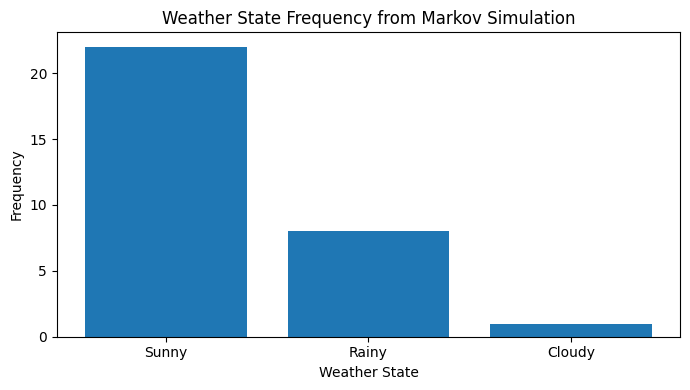

In [8]:
config.output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(7, 4))
plt.bar(config.states, [counts[s] for s in config.states])
plt.xlabel("Weather State")
plt.ylabel("Frequency")
plt.title("Weather State Frequency from Markov Simulation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(config.output_dir / config.chart_file, dpi=150)
plt.show()


In [9]:
metrics = {
    "start_state": config.start_state,
    "num_steps": config.num_steps,
    "seed": config.seed,
    "history": history,
    "state_counts": counts,
    "stationary_distribution": {
        state: float(prob) for state, prob in zip(config.states, stationary_distribution)
    },
    "transition_matrix": transition_matrix.tolist(),
}

with open(config.output_dir / config.metrics_file, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to: {config.output_dir / config.metrics_file}")
print(f"Saved chart to: {config.output_dir / config.chart_file}")


Saved metrics to: results\weather_metrics.json
Saved chart to: results\weather_state_frequency.png
